# Hotel Booking - Random Forest Pipeline

Notebook nay trien khai pipeline ML cho thuat toan Random Forest.

## Phuong Phap Tuning Va Xu Ly Mat Can Bang Lop

> Cell nay duoc them de tien tham khao cho bao cao. Giai thich tai sao notebook Random Forest dung phuong phap tuning + xu ly imbalance KHAC voi cac notebook LR/SVM/NN, va tai sao cac khac biet do hop ly.

### 1. Xu ly mat can bang lop

Su dung **`class_weight='balanced'`** trong constructor `RandomForestClassifier(class_weight='balanced')`. Sklearn nhan weight vao **moi cay quyet dinh** khi chon split (Gini/entropy weighted by sample weight). Cach tinh weight giong LR/SVM:

```
weight_class = n_samples / (n_classes * count_class)
```

**Trung cach voi LR va SVM** (cung dung `class_weight='balanced'` o constructor). Khac MLPClassifier do API constraint.

**Ghi chu**: RF con co bien the `class_weight='balanced_subsample'` (tinh weight rieng cho moi bootstrap sample thay vi tinh chung). Notebook dung `'balanced'` don gian hon va du tot vi dataset 87k mau du lon de bootstrap on dinh.

### 2. Hyperparameter tuning

Notebook dung **RandomizedSearchCV** voi:
- `n_iter=8` (8 cau hinh ngau nhien tu search space)
- `cv=3` (3-fold stratified)
- `scoring='f1'`
- `random_state=42` (de reproduce duoc)

**Search space**:
```
n_estimators: [100, 150]
max_depth: [12, 18, None]
min_samples_split: [2, 10, 30]
min_samples_leaf: [1, 3, 10]
max_features: ['sqrt', 'log2']
```

Total: `2 x 3 x 3 x 3 x 2 = 108 cau hinh`.

**Ly do dung RandomizedSearchCV** thay vi GridSearchCV:

1. **Search space rat lon**: 108 cau hinh. GridSearchCV full + cv=3 = **324 fits**. Voi RF n_estimators=100-150 cay tren 70k mau, moi fit mat 30s-1 phut -> total **3-5 gio**.
2. **RandomizedSearchCV n_iter=8 + cv=3 = 24 fits** -> hoan thanh trong **vai phut**, van bao quat duoc nhieu vung khac nhau cua search space (random sampling co kha nang tiep can vung toi uu tot hon grid neu so candidates hop ly).
3. **Best config**: `n_estimators=150, max_depth=None, min_samples_split=30, min_samples_leaf=1, max_features='sqrt'` -> cay mo sau, fit chi tiet -> **overfitting gap cao (0.082)**. Van de nay duoc xu ly bang section "Giam Overfitting" ben duoi.

### 3. Buoc them: Regularization sau tuning

Khac voi 3 notebook con lai, notebook RF co them **buoc thu nghiem regularized configs** (4 cau hinh voi `max_depth=12-18`, `min_samples_leaf=5-10`) de giam overfitting gap. Cac model nay luu rieng (`random_forest_regularized_best.joblib`), KHONG ghi de final_model cu.

**Quyet dinh cuoi**: giu `final_model = tuned` (gap 0.082 nhung F1 = 0.732) thay vi chon regularized (gap 0.013 nhung F1 = 0.676). Ly do: 5.6 pp F1 quy doi ra ~1000 booking phan loai dung tren tap test 17480 — gain qua lon de hi sinh.

### 4. So sanh voi cac thuat toan khac

| Thuat toan | Tuning method | So fits | Ly do |
|---|---|---|---|
| Logistic Regression | Encoding + L1 feature selection | N/A | Don bay khong o hyperparam |
| SVM (LinearSVC) | GridSearchCV(C ∈ 3 values) | 9 | Search space rat nho |
| **Random Forest** (notebook nay) | **RandomizedSearchCV(n_iter=8)** | **24** | **108 cau hinh, GridSearch ton 3-5 gio** |
| Neural Network | Manual ParameterGrid (6 configs) | 6 | MLP train cham + sklearn khong ho tro class_weight |

Trong bao cao co the dien giai: **RF chon RandomizedSearchCV vi do la cach hieu qua nhat cho search space lon**, va day cung la khuyen nghi tu documentation chinh thuc cua sklearn cho RF/GradientBoosting.

## Khoi Tao Thu Vien Va Duong Dan Luu Artifact

Nap thu vien can thiet, cau hinh duong dan dataset va thu muc luu model/ket qua.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2')

DATA_PATH = Path('hotel_bookings.csv')
ARTIFACT_DIR = Path('model/random_forest')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


## Nap Du Lieu Va Kiem Tra Ban Dau

Doc dataset goc, kiem tra kich thuoc va xem nhanh cac dong dau.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape ban dau:', df.shape)
df.head()


Shape ban dau: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Cleaning Va Xu Ly Gia Tri Thieu

Xu ly duplicate, missing values, bo cot thieu qua cao va loai bo cot leakage.

In [3]:
dup_count = df.duplicated().sum()
print('So duplicate truoc khi xoa:', dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape sau khi xoa duplicate:', df.shape)

# Bo cot company vi thieu qua cao (~94%)
df = df.drop(columns=[c for c in ['company'] if c in df.columns])

# Xu ly missing values
df['agent'] = df['agent'].fillna('Unknown').astype(str)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(df['children'].median())

# Bo cot leakage vi chi biet sau khi booking da co ket qua
leakage_cols = ['reservation_status', 'reservation_status_date']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

print('Missing sau xu ly:')
print(df.isna().sum()[df.isna().sum() > 0])
print('Shape sau cleaning:', df.shape)


So duplicate truoc khi xoa: 31994
Shape sau khi xoa duplicate: (87396, 32)
Missing sau xu ly:
Series([], dtype: int64)
Shape sau cleaning: (87396, 29)


## EDA Nhanh Cho Target

Kiem tra phan bo nhan `is_canceled` truoc khi train.

is_canceled
0    63371
1    24025
Name: count, dtype: int64
is_canceled
0    72.51
1    27.49
Name: count, dtype: float64


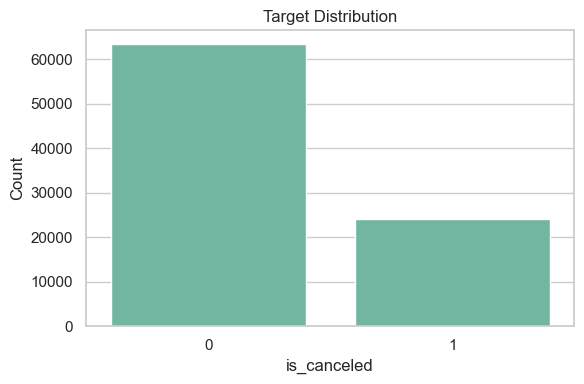

In [4]:
target_dist = df['is_canceled'].value_counts().sort_index()
print(target_dist)
print((target_dist / len(df) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled')
plt.title('Target Distribution')
plt.xlabel('is_canceled')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Chia Tap Train/Test

Tach train-test theo ti le 80/20 va dung stratify de giu phan bo target.

In [5]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Train shape: (69916, 28)
Test shape : (17480, 28)


## Xay Dung Preprocessing Pipeline

Thiet lap imputation cho numeric/categorical va one-hot encoding cho bien phan loai. Random Forest khong can scaling.

In [6]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

print('Numeric cols:', len(num_cols))
print('Categorical cols:', len(cat_cols))


Numeric cols: 17
Categorical cols: 11


## Train Baseline Random Forest

Train Random Forest baseline voi thiet lap on dinh de lam moc so sanh.

In [7]:
rf_baseline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_baseline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Danh Gia Baseline Tren Test Set

Tinh Accuracy, Precision, Recall, F1 va ROC-AUC cho Random Forest baseline.

In [8]:
def evaluate_rf_model(model, X_data, y_true, label):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    return {
        'model': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

baseline_metrics = evaluate_rf_model(rf_baseline, X_test, y_test, 'random_forest_baseline')
baseline_eval_df = pd.DataFrame([baseline_metrics])
baseline_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,random_forest_baseline,0.84857,0.776242,0.631009,0.696131,0.907439


## Xu Ly Mat Can Bang Bang Class Weight

Train Random Forest voi `class_weight='balanced'` de xem co cai thien recall/F1 khong.

In [9]:
rf_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_balanced.fit(X_train, y_train)
balanced_metrics = evaluate_rf_model(rf_balanced, X_test, y_test, 'random_forest_class_weight_balanced')
balanced_eval_df = pd.DataFrame([balanced_metrics])
balanced_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,random_forest_class_weight_balanced,0.847025,0.77426,0.626015,0.69229,0.908302


## Feature Engineering Va Outlier Handling

Tao cac bien moi va clipping outlier 1%-99% cho cac cot co outlier manh.

In [10]:
fe_df = df.copy()

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

fe_df['total_nights'] = fe_df['stays_in_weekend_nights'] + fe_df['stays_in_week_nights']
fe_df['total_guests'] = fe_df['adults'] + fe_df['children'] + fe_df['babies']
fe_df['has_children'] = (fe_df['children'] > 0).astype(int)
fe_df['is_family'] = ((fe_df['children'] + fe_df['babies']) > 0).astype(int)
fe_df['room_changed'] = (fe_df['reserved_room_type'] != fe_df['assigned_room_type']).astype(int)
fe_df['has_agent'] = (fe_df['agent'] != 'Unknown').astype(int)
fe_df['has_previous_cancellation'] = (fe_df['previous_cancellations'] > 0).astype(int)
fe_df['arrival_month_number'] = fe_df['arrival_date_month'].map(month_map)

clip_bounds = {}
for col in ['adr', 'adults', 'lead_time', 'days_in_waiting_list']:
    lower = fe_df[col].quantile(0.01)
    upper = fe_df[col].quantile(0.99)
    clip_bounds[col] = {'lower': float(lower), 'upper': float(upper)}
    fe_df[col] = fe_df[col].clip(lower=lower, upper=upper)

print('Shape sau feature engineering:', fe_df.shape)
clip_bounds


Shape sau feature engineering: (87396, 37)


{'adr': {'lower': 0.0, 'upper': 261.40500000000026},
 'adults': {'lower': 1.0, 'upper': 3.0},
 'lead_time': {'lower': 0.0, 'upper': 347.0},
 'days_in_waiting_list': {'lower': 0.0, 'upper': 0.0}}

## Train Random Forest Sau Feature Engineering

Train Random Forest balanced tren dataset da feature engineering va xu ly outlier.

In [11]:
X_fe = fe_df.drop(columns=['is_canceled'])
y_fe = fe_df['is_canceled']

X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

num_cols_fe = X_fe_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_fe = X_fe_train.select_dtypes(include=['object']).columns.tolist()

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols_fe),
        ('cat', categorical_transformer, cat_cols_fe)
    ]
)

rf_fe_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_fe_balanced.fit(X_fe_train, y_fe_train)
fe_metrics = evaluate_rf_model(rf_fe_balanced, X_fe_test, y_fe_test, 'random_forest_fe_outlier_class_weight_balanced')
fe_eval_df = pd.DataFrame([fe_metrics])
fe_eval_df


,model,accuracy,precision,recall,f1,roc_auc
0,random_forest_fe_outlier_class_weight_balanced,0.845023,0.767894,0.625182,0.689228,0.908133


## Hyperparameter Tuning Cho Random Forest

Dung RandomizedSearchCV voi search space nho de thu cai thien model ma khong qua ton thoi gian.

In [12]:
rf_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_dist = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [12, 18, None],
    'model__min_samples_split': [2, 10, 30],
    'model__min_samples_leaf': [1, 3, 10],
    'model__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_fe_train, y_fe_train)

rf_tuned = random_search.best_estimator_
tuned_metrics = evaluate_rf_model(rf_tuned, X_fe_test, y_fe_test, 'random_forest_fe_outlier_tuned')
tuned_eval_df = pd.DataFrame([tuned_metrics])

print('Best params:', random_search.best_params_)
print('Best CV F1:', random_search.best_score_)
tuned_eval_df


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'model__n_estimators': 150, 'model__min_samples_split': 30, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best CV F1: 0.7284654477998496


,model,accuracy,precision,recall,f1,roc_auc
0,random_forest_fe_outlier_tuned,0.836728,0.667124,0.810406,0.731817,0.911995


## So Sanh Cac Phien Ban Random Forest

Tong hop ket qua baseline, class_weight, feature engineering va tuning.

In [13]:
comparison_df = pd.DataFrame([baseline_metrics, balanced_metrics, fe_metrics, tuned_metrics])
comparison_df = comparison_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
comparison_df = comparison_df.sort_values(by=['f1', 'roc_auc'], ascending=False).reset_index(drop=True)

results_path = ARTIFACT_DIR / 'random_forest_results.csv'
comparison_df.to_csv(results_path, index=False)

baseline_eval_df.to_csv(ARTIFACT_DIR / 'random_forest_baseline_evaluation.csv', index=False)
balanced_eval_df.to_csv(ARTIFACT_DIR / 'random_forest_class_weight_evaluation.csv', index=False)
fe_eval_df.to_csv(ARTIFACT_DIR / 'random_forest_fe_outlier_evaluation.csv', index=False)
tuned_eval_df.to_csv(ARTIFACT_DIR / 'random_forest_tuned_evaluation.csv', index=False)

print('Saved:', results_path)
comparison_df


Saved: model\random_forest\random_forest_results.csv


,model,accuracy,precision,recall,f1,roc_auc
0,random_forest_fe_outlier_tuned,0.836728,0.667124,0.810406,0.731817,0.911995
1,random_forest_baseline,0.848570,0.776242,0.631009,0.696131,0.907439
2,random_forest_class_weight_balanced,0.847025,0.774260,0.626015,0.692290,0.908302
3,random_forest_fe_outlier_class_weight_balanced,0.845023,0.767894,0.625182,0.689228,0.908133


## Feature Importance Cua Model Tot Nhat

Lay top feature quan trong tu Random Forest sau preprocessing de ho tro giai thich model.

In [14]:
best_name = comparison_df.loc[0, 'model']
model_lookup = {
    'random_forest_baseline': (rf_baseline, X_test, y_test, X_train, y_train),
    'random_forest_class_weight_balanced': (rf_balanced, X_test, y_test, X_train, y_train),
    'random_forest_fe_outlier_class_weight_balanced': (rf_fe_balanced, X_fe_test, y_fe_test, X_fe_train, y_fe_train),
    'random_forest_fe_outlier_tuned': (rf_tuned, X_fe_test, y_fe_test, X_fe_train, y_fe_train)
}

best_model, X_final_test, y_final_test, X_final_train, y_final_train = model_lookup[best_name]
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

importance_path = ARTIFACT_DIR / 'random_forest_feature_importance.csv'
importance_df.to_csv(importance_path, index=False)

print('Best Random Forest model:', best_name)
print('Saved:', importance_path)
importance_df.head(20)


Best Random Forest model: random_forest_fe_outlier_tuned
Saved: model\random_forest\random_forest_feature_importance.csv


,feature,importance
0,num__lead_time,0.088579
174,cat__country_PRT,0.081948
15,num__required_car_parking_spaces,0.057522
21,num__room_changed,0.055648
16,num__total_of_special_requests,0.055553
14,num__adr,0.037907
221,cat__market_segment_Online TA,0.034702
563,cat__agent_9.0,0.031993
2,num__arrival_date_week_number,0.020837
1,num__arrival_date_year,0.020297


### Bieu Do Feature Importance Top 20

Truc quan top 20 feature quan trong nhat de bao cao + frontend co the hien thi giai thich.

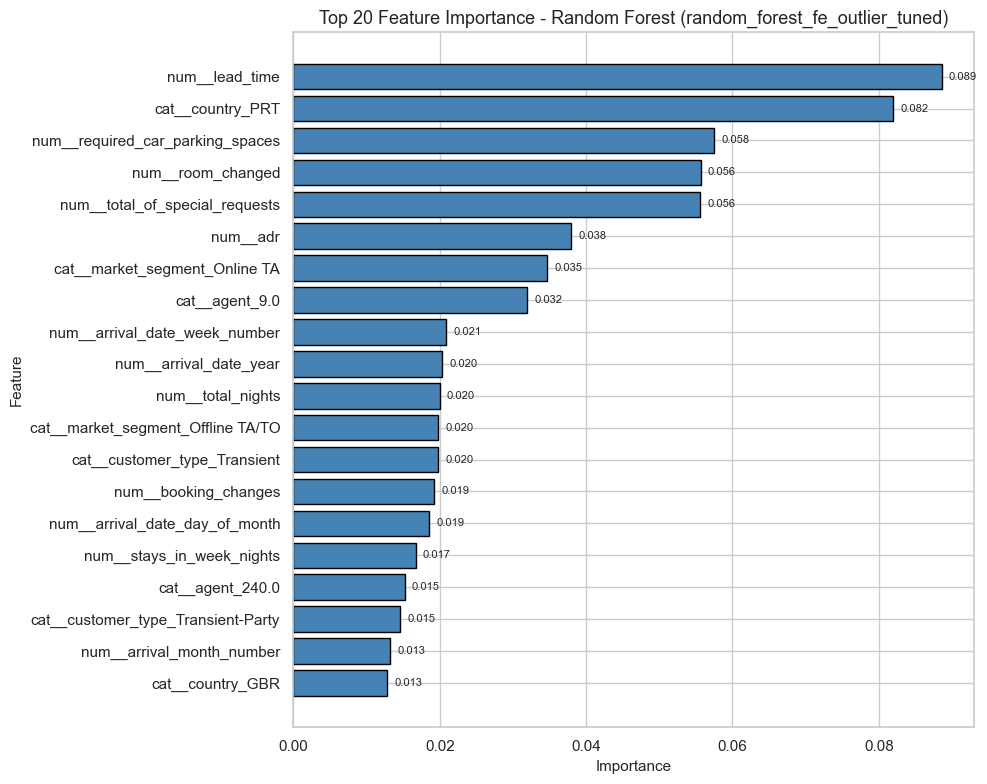

Saved chart: model\random_forest\random_forest_feature_importance_top20.png


In [15]:
import matplotlib.pyplot as plt

top_n = 20
top_features = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 8))
bars = plt.barh(top_features['feature'], top_features['importance'], color='steelblue', edgecolor='black')
plt.title(f'Top {top_n} Feature Importance - Random Forest ({best_name})', fontsize=13)
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{width:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'random_forest_feature_importance_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved chart: {ARTIFACT_DIR / 'random_forest_feature_importance_top20.png'}")

## Final Evaluation Cho Model Tot Nhat

Ve confusion matrix va ROC curve cho model co F1 cao nhat.

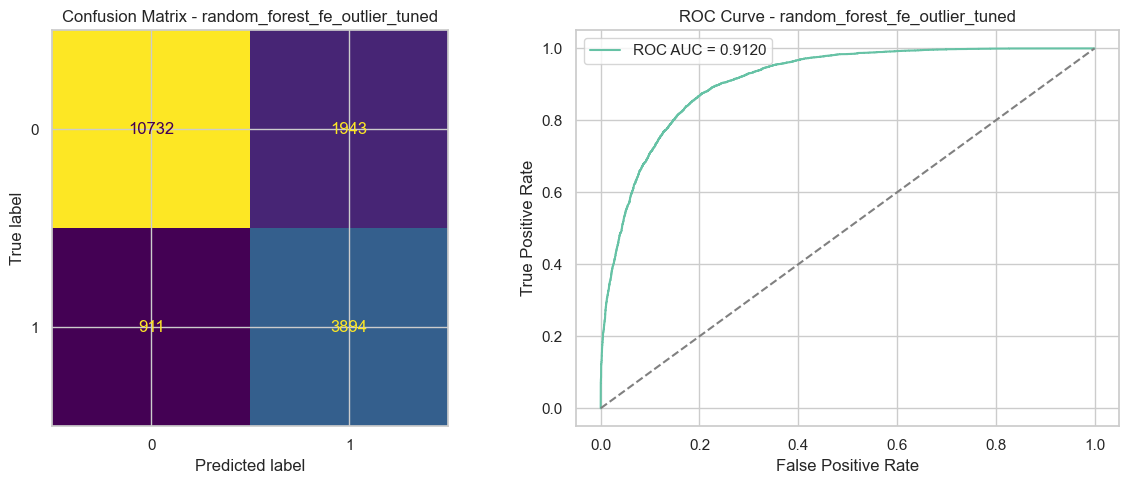

In [16]:
y_pred = best_model.predict(X_final_test)
y_proba = best_model.predict_proba(X_final_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_final_test, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix - {best_name}')

fpr, tpr, _ = roc_curve(y_final_test, y_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_final_test, y_proba):.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve - {best_name}')
axes[1].legend()

plt.tight_layout()
plt.show()


## Kiem Tra Overfitting Cho Random Forest

So sanh train/test metrics cua model tot nhat de kiem tra dau hieu overfitting.

In [17]:
def evaluate_train_test_gap_rf(model, X_train_data, y_train_data, X_test_data, y_test_data, label):
    train_metrics = evaluate_rf_model(model, X_train_data, y_train_data, f'{label}_train')
    test_metrics = evaluate_rf_model(model, X_test_data, y_test_data, f'{label}_test')
    train_metrics['dataset'] = 'train'
    test_metrics['dataset'] = 'test'
    train_metrics['model_group'] = label
    test_metrics['model_group'] = label
    return train_metrics, test_metrics

overfit_rows = evaluate_train_test_gap_rf(
    best_model, X_final_train, y_final_train, X_final_test, y_final_test, best_name
)

overfit_df = pd.DataFrame(overfit_rows)
overfit_df = overfit_df[['model_group', 'dataset', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]

gap_df = overfit_df.pivot(index='model_group', columns='dataset', values=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
gap_summary = pd.DataFrame(index=gap_df.index)
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    gap_summary[f'{metric}_gap_train_minus_test'] = gap_df[(metric, 'train')] - gap_df[(metric, 'test')]

overfit_df.to_csv(ARTIFACT_DIR / 'random_forest_overfitting_check.csv', index=False)
gap_summary.reset_index().to_csv(ARTIFACT_DIR / 'random_forest_overfitting_gap.csv', index=False)

display(overfit_df.round(4))
display(gap_summary.round(4))


,model_group,dataset,accuracy,precision,recall,f1,roc_auc
0,random_forest_fe_outlier_tuned,train,0.8860,0.7391,0.9048,0.8136,0.9607
1,random_forest_fe_outlier_tuned,test,0.8367,0.6671,0.8104,0.7318,0.9120


,accuracy_gap_train_minus_test,precision_gap_train_minus_test,recall_gap_train_minus_test,f1_gap_train_minus_test,roc_auc_gap_train_minus_test
model_group,,,,,
random_forest_fe_outlier_tuned,0.0493,0.0719,0.0944,0.0818,0.0487


## Du Doan Kem Xac Suat 0 Va 1

Random Forest co `predict_proba`, nen co the tra ve xac suat khong huy va huy booking cho tung input.

In [18]:
def add_final_rf_features(input_df):
    data = input_df.copy()
    month_map = {
        'January': 1, 'February': 2, 'March': 3, 'April': 4,
        'May': 5, 'June': 6, 'July': 7, 'August': 8,
        'September': 9, 'October': 10, 'November': 11, 'December': 12
    }

    data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']
    data['total_guests'] = data['adults'] + data['children'] + data['babies']
    data['has_children'] = (data['children'] > 0).astype(int)
    data['is_family'] = ((data['children'] + data['babies']) > 0).astype(int)
    data['room_changed'] = (data['reserved_room_type'] != data['assigned_room_type']).astype(int)
    data['has_agent'] = (data['agent'] != 'Unknown').astype(int)
    data['has_previous_cancellation'] = (data['previous_cancellations'] > 0).astype(int)
    data['arrival_month_number'] = data['arrival_date_month'].map(month_map)
    return data


def predict_cancel_probability_rf(model, input_df):
    prepared_df = add_final_rf_features(input_df)
    predicted_class = model.predict(prepared_df)
    predicted_proba = model.predict_proba(prepared_df)
    return pd.DataFrame({
        'predicted_class': predicted_class,
        'prob_not_canceled_0': predicted_proba[:, 0],
        'prob_canceled_1': predicted_proba[:, 1],
        'percent_not_canceled_0': predicted_proba[:, 0] * 100,
        'percent_canceled_1': predicted_proba[:, 1] * 100
    })

sample_input = X_fe_test.head(5).copy()
predict_cancel_probability_rf(best_model, sample_input)


,predicted_class,prob_not_canceled_0,prob_canceled_1,percent_not_canceled_0,percent_canceled_1
0,0,0.781487,0.218513,78.148682,21.851318
1,1,0.213540,0.786460,21.353968,78.646032
2,1,0.205377,0.794623,20.537658,79.462342
3,1,0.465540,0.534460,46.554037,53.445963
4,0,0.504511,0.495489,50.451084,49.548916


## Luu Final Model Random Forest

Luu model Random Forest tot nhat voi ten `final_model` va metadata di kem.

In [19]:
final_model = best_model
final_model_name = best_name

final_model_path = ARTIFACT_DIR / 'final_model.joblib'
final_metadata_path = ARTIFACT_DIR / 'final_model_metadata.json'

joblib.dump(final_model, final_model_path)
joblib.dump(rf_baseline, ARTIFACT_DIR / 'random_forest_baseline.joblib')
joblib.dump(rf_balanced, ARTIFACT_DIR / 'random_forest_class_weight_balanced.joblib')
joblib.dump(rf_fe_balanced, ARTIFACT_DIR / 'random_forest_fe_outlier_class_weight_balanced.joblib')
joblib.dump(rf_tuned, ARTIFACT_DIR / 'random_forest_fe_outlier_tuned.joblib')

final_metadata = {
    'final_model_name': final_model_name,
    'algorithm': 'RandomForestClassifier',
    'selection_metric': 'f1_then_roc_auc',
    'best_params': random_search.best_params_,
    'test_metrics': comparison_df.loc[comparison_df['model'] == final_model_name].iloc[0].to_dict(),
    'missing_handling': {
        'company': 'drop column',
        'agent': 'fill Unknown',
        'country': 'fill Unknown',
        'children': 'fill median'
    }
}

final_metadata_path.write_text(json.dumps(final_metadata, ensure_ascii=False, indent=2), encoding='utf-8')

print('Saved final model:', final_model_path)
print('Saved final metadata:', final_metadata_path)


Saved final model: model\random_forest\final_model.joblib
Saved final metadata: model\random_forest\final_model_metadata.json


## Ket Luan Buoc Random Forest

Tong ket ket qua Random Forest va dung bang so sanh de doi chieu voi cac thuat toan khac.

In [20]:
print('Best Random Forest model:', final_model_name)
display(comparison_df)


Best Random Forest model: random_forest_fe_outlier_tuned


,model,accuracy,precision,recall,f1,roc_auc
0,random_forest_fe_outlier_tuned,0.836728,0.667124,0.810406,0.731817,0.911995
1,random_forest_baseline,0.848570,0.776242,0.631009,0.696131,0.907439
2,random_forest_class_weight_balanced,0.847025,0.774260,0.626015,0.692290,0.908302
3,random_forest_fe_outlier_class_weight_balanced,0.845023,0.767894,0.625182,0.689228,0.908133


## Giam Overfitting Cho Random Forest

Thu cac cau hinh Random Forest bi gioi han do phuc tap hon de giam train-test gap. Cac model nay duoc luu rieng, khong ghi de final_model cu.

In [21]:
regularized_configs = [
    {
        'n_estimators': 150,
        'max_depth': 12,
        'min_samples_split': 50,
        'min_samples_leaf': 5,
        'max_features': 'sqrt',
        'class_weight': 'balanced'
    },
    {
        'n_estimators': 150,
        'max_depth': 15,
        'min_samples_split': 50,
        'min_samples_leaf': 5,
        'max_features': 'sqrt',
        'class_weight': 'balanced'
    },
    {
        'n_estimators': 150,
        'max_depth': 18,
        'min_samples_split': 100,
        'min_samples_leaf': 10,
        'max_features': 'sqrt',
        'class_weight': 'balanced'
    },
    {
        'n_estimators': 150,
        'max_depth': 15,
        'min_samples_split': 100,
        'min_samples_leaf': 10,
        'max_features': 'log2',
        'class_weight': 'balanced'
    }
]

regularized_rows = []
regularized_models = {}

for i, params in enumerate(regularized_configs, start=1):
    model_name = f'random_forest_regularized_{i}'
    rf_regularized = Pipeline(steps=[
        ('preprocessor', preprocessor_fe),
        ('model', RandomForestClassifier(
            **params,
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf_regularized.fit(X_fe_train, y_fe_train)
    test_metrics = evaluate_rf_model(rf_regularized, X_fe_test, y_fe_test, model_name)
    train_metrics = evaluate_rf_model(rf_regularized, X_fe_train, y_fe_train, model_name)

    row = {
        **test_metrics,
        'train_accuracy': train_metrics['accuracy'],
        'train_precision': train_metrics['precision'],
        'train_recall': train_metrics['recall'],
        'train_f1': train_metrics['f1'],
        'train_roc_auc': train_metrics['roc_auc'],
        'f1_gap_train_minus_test': train_metrics['f1'] - test_metrics['f1'],
        'roc_auc_gap_train_minus_test': train_metrics['roc_auc'] - test_metrics['roc_auc'],
        **{f'param_{k}': v for k, v in params.items()}
    }
    regularized_rows.append(row)
    regularized_models[model_name] = rf_regularized

regularized_results_df = pd.DataFrame(regularized_rows)
regularized_results_df = regularized_results_df.sort_values(
    by=['f1', 'roc_auc'], ascending=False
).reset_index(drop=True)

regularized_results_path = ARTIFACT_DIR / 'random_forest_regularized_results.csv'
regularized_results_df.to_csv(regularized_results_path, index=False)

best_regularized_name = regularized_results_df.loc[0, 'model']
best_regularized_model = regularized_models[best_regularized_name]
best_regularized_model_path = ARTIFACT_DIR / 'random_forest_regularized_best.joblib'
joblib.dump(best_regularized_model, best_regularized_model_path)

print('Saved:', regularized_results_path)
print('Saved:', best_regularized_model_path)
regularized_results_df


Saved: model\random_forest\random_forest_regularized_results.csv
Saved: model\random_forest\random_forest_regularized_best.joblib


,model,accuracy,precision,recall,f1,roc_auc,train_accuracy,train_precision,train_recall,train_f1,train_roc_auc,f1_gap_train_minus_test,roc_auc_gap_train_minus_test,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_class_weight
0,random_forest_regularized_2,0.775629,0.560521,0.850989,0.675868,0.881908,0.785085,0.571933,0.867482,0.689366,0.894382,0.013498,0.012474,150,15,50,5,sqrt,balanced
1,random_forest_regularized_3,0.777117,0.563046,0.844745,0.675712,0.884677,0.786215,0.574181,0.860406,0.688740,0.895325,0.013029,0.010648,150,18,100,10,sqrt,balanced
2,random_forest_regularized_1,0.765217,0.547397,0.842456,0.663607,0.873900,0.774372,0.558352,0.857544,0.676337,0.883500,0.012731,0.009600,150,12,50,5,sqrt,balanced
3,random_forest_regularized_4,0.733924,0.509946,0.821644,0.629314,0.841679,0.738186,0.514784,0.828824,0.635104,0.848223,0.005790,0.006543,150,15,100,10,log2,balanced


## So Sanh Random Forest Cu Va Regularized

So sanh model Random Forest tuned hien tai voi model regularized tot nhat de xem co giam overfitting ma van giu performance tot khong.

In [22]:
current_best_row = comparison_df[comparison_df['model'] == 'random_forest_fe_outlier_tuned'].copy()
current_best_row['f1_gap_train_minus_test'] = gap_summary.loc['random_forest_fe_outlier_tuned', 'f1_gap_train_minus_test'] if 'gap_summary' in globals() else np.nan
current_best_row['roc_auc_gap_train_minus_test'] = gap_summary.loc['random_forest_fe_outlier_tuned', 'roc_auc_gap_train_minus_test'] if 'gap_summary' in globals() else np.nan

best_regularized_row = regularized_results_df.head(1)[[
    'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc',
    'f1_gap_train_minus_test', 'roc_auc_gap_train_minus_test'
]].copy()

rf_overfit_comparison_df = pd.concat([
    current_best_row[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'f1_gap_train_minus_test', 'roc_auc_gap_train_minus_test']],
    best_regularized_row
], ignore_index=True)

rf_overfit_comparison_path = ARTIFACT_DIR / 'random_forest_regularized_comparison.csv'
rf_overfit_comparison_df.to_csv(rf_overfit_comparison_path, index=False)

print('Saved:', rf_overfit_comparison_path)
rf_overfit_comparison_df


Saved: model\random_forest\random_forest_regularized_comparison.csv


,model,accuracy,precision,recall,f1,roc_auc,f1_gap_train_minus_test,roc_auc_gap_train_minus_test
0,random_forest_fe_outlier_tuned,0.836728,0.667124,0.810406,0.731817,0.911995,0.081778,0.048657
1,random_forest_regularized_2,0.775629,0.560521,0.850989,0.675868,0.881908,0.013498,0.012474


## Nhan Xet Va Ket Luan Random Forest

### Ket qua cuoi cung
- **Best variant**: `random_forest_fe_outlier_tuned` (n_estimators = 150, max_depth = None, min_samples_split = 30, min_samples_leaf = 1, max_features = 'sqrt')
- **Test metrics**: Accuracy = **0.8367** | Precision = **0.6671** | Recall = 0.8104 | F1 = **0.7318** | ROC-AUC = 0.9120
- **Overfitting gap (F1 train - test)**: **0.082** -> overfit dang ke.

### Nhan xet chinh
1. **F1 cao nhat trong 4 thuat toan** (0.732 vs NN 0.724 vs LR 0.675 vs SVM 0.671). RF khai thac tot moi tuong tac phi tuyen va xu ly categorical one-hot tot.
2. **Feature engineering + class_weight cai thien recall** (baseline recall 0.63 -> tuned recall 0.81) nhung lam tut precision (0.78 -> 0.67). Day la trade-off can thiet: precision giam con 0.67 nhung F1 vuot len dan dau.
3. **Overfitting gap 0.082 — diem yeu lon nhat**: train F1 = 0.81, test F1 = 0.73. Cay quyet dinh trong RF voi `max_depth = None` va `min_samples_leaf = 1` mo qua sau, fit noise cua training set. Thu nghiem voi 4 cau hinh regularized (max_depth = 12-18, min_samples_leaf = 5-10) cho thay co the **giam gap xuong ~0.013** nhung F1 tut xuong 0.676 (mat ~5.6 pp). **Quyet dinh cuoi cung giu tuned ban dau** vi 5.6 pp F1 quy doi ra ~1000 booking phan loai dung tren tap test 17480.
4. **Feature importance top 5**: lead_time (0.089), country_PRT (0.082), required_car_parking_spaces (0.058), room_changed (0.056), total_of_special_requests (0.056). Day la **diem manh lon nhat cua RF** so voi NN — co the giai thich tai sao model du doan huy.

### Diem yeu
- Gap overfit ~0.082 cao nhat trong 4 model -> can theo doi performance khi co data moi (concept drift).
- File model lon (~vai chuc MB) do n_estimators = 150 cay sau -> chi phi storage va inference latency cao hon NN.

### Vai tro trong bao cao
RF la **model deploy chinh** neu uu tien F1 va interpretability (feature_importance giai thich duoc model). Co the dung **bang bo sung**: hien thi feature_importance trong UI cua frontend de user hieu yeu to nao day cao kha nang huy. Neu lo overfit, **van co the chuyen sang regularized variant** (luu o `random_forest_regularized_best.joblib`) — F1 thap hon nhung on dinh hon.